# Phase 4 - Model Development

## Objective

The objective of this phase is to build and compare multiple regression models for predicting house prices.

All models are trained using the same training and testing datasets to ensure a fair comparison. The performance of each model is evaluated using standard regression metrics.

### Models

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- LightGBM Regressor
- CatBoost Regressor

### Evaluation Metrics

- MAE
- MSE
- RMSE
- R² Score

The best-performing model will be selected for further optimization in the next phase.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install xgboost lightgbm catboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [4]:
# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,4.189655,9.042040,7,5,2003,2003,5.283204,6.561031,...,0,0,0,1,0,5,3.500000,20.257977,4.127134,0
1,2,3.044522,4.394449,9.169623,6,8,1976,1976,0.000000,6.886532,...,0,0,0,1,0,31,2.346574,14.282490,0.000000,0
2,3,4.110874,4.234107,9.328212,7,5,2001,2002,5.093750,6.188264,...,0,0,0,1,0,7,3.500000,20.415959,3.761200,1
3,4,4.262680,4.110874,9.164401,7,5,1915,1970,0.000000,5.379897,...,0,0,0,0,0,91,2.000000,20.127741,9.192991,1
4,5,4.110874,4.442651,9.565284,8,5,2000,2000,5.860786,6.486161,...,0,0,0,1,0,8,3.500000,21.048414,4.442651,0


In [6]:
# Fill Remaining Missing Values

num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    

In [7]:
print(df.isnull().sum().sum())

0


In [8]:
# Features and Target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [9]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Model Evaluation Function

results = []

def evaluate_model(name, model, Xtrain, Xtest):
    
    model.fit(Xtrain, y_train)

    prediction = model.predict(Xtest)

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    results.append([name, mae, mse, rmse, r2])

    print(f"{name} Completed")

In [12]:
# Linear Regression
from sklearn.linear_model import LinearRegression


linear = LinearRegression()

evaluate_model(
    "Linear Regression",
    linear,
    X_train_scaled,
    X_test_scaled
)

Linear Regression Completed


In [13]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

Id                0
MSSubClass        0
LotFrontage       0
LotArea           0
OverallQual       0
                 ..
HouseAge          0
TotalBathrooms    0
TotalSF           0
TotalPorchArea    0
RemodeledHouse    0
Length: 240, dtype: int64

In [14]:
# Total Missing Values
print(df.isnull().sum().sum())

0


In [15]:
# Decision Tree

dt = DecisionTreeRegressor(
    random_state=42
)

evaluate_model(
    "Decision Tree",
    dt,
    X_train,
    X_test
)

Decision Tree Completed


In [16]:
# Random Forest

rf = RandomForestRegressor(
    random_state=42
)

evaluate_model(
    "Random Forest",
    rf,
    X_train,
    X_test
)

Random Forest Completed


In [17]:
# Gradient Boosting

gb = GradientBoostingRegressor(
    random_state=42
)

evaluate_model(
    "Gradient Boosting",
    gb,
    X_train,
    X_test
)

Gradient Boosting Completed


In [18]:
# XGBoost

xgb = XGBRegressor(
    random_state=42,
    verbosity=0
)

evaluate_model(
    "XGBoost",
    xgb,
    X_train,
    X_test
)

XGBoost Completed


In [19]:
# LightGBM

lgbm = LGBMRegressor(
    random_state=42
)

evaluate_model(
    "LightGBM",
    lgbm,
    X_train,
    X_test
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3974
[LightGBM] [Info] Number of data points in the train set: 1119, number of used features: 154
[LightGBM] [Info] Start training from score 171335.218945
LightGBM Completed


In [20]:
# CatBoost

cb = CatBoostRegressor(
    random_state=42,
    verbose=0
)

evaluate_model(
    "CatBoost",
    cb,
    X_train,
    X_test
)

CatBoost Completed


In [21]:
# Model Comparison

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,16837.207398,1.191990e+09,34525.206485,0.625257
1,Decision Tree,23677.432143,1.172576e+09,34242.902612,0.631360
2,Random Forest,14043.607250,4.354628e+08,20867.744897,0.863097
3,Gradient Boosting,13284.836044,3.576519e+08,18911.687912,0.887560
4,XGBoost,14013.219727,4.109945e+08,20272.999975,0.870790
5,LightGBM,13469.373309,3.833403e+08,19579.078554,0.879484
6,CatBoost,11480.855107,2.794843e+08,16717.783610,0.912134


In [22]:
# Sort Models
# Sort Models by R2 Score
comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison

,Model,MAE,MSE,RMSE,R2 Score
6,CatBoost,11480.855107,2.794843e+08,16717.783610,0.912134
3,Gradient Boosting,13284.836044,3.576519e+08,18911.687912,0.887560
5,LightGBM,13469.373309,3.833403e+08,19579.078554,0.879484
4,XGBoost,14013.219727,4.109945e+08,20272.999975,0.870790
2,Random Forest,14043.607250,4.354628e+08,20867.744897,0.863097
1,Decision Tree,23677.432143,1.172576e+09,34242.902612,0.631360
0,Linear Regression,16837.207398,1.191990e+09,34525.206485,0.625257


In [23]:
# Save Model Comparison Report
comparison.to_csv(
    "/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/reports/model_comparison.csv",
    index=False
)

print("Model comparison report saved successfully.")

Model comparison report saved successfully.


In [24]:
# Display Best Model
best_model = comparison.iloc[0]

print("Best Performing Model")
print("----------------------")
print("Model :", best_model["Model"])
print("MAE :", best_model["MAE"])
print("MSE :", best_model["MSE"])
print("RMSE :", best_model["RMSE"])
print("R2 Score :", best_model["R2 Score"])

Best Performing Model
----------------------
Model : CatBoost
MAE : 11480.855107050073
MSE : 279484288.8194067
RMSE : 16717.783609659706
R2 Score : 0.9121344441099607


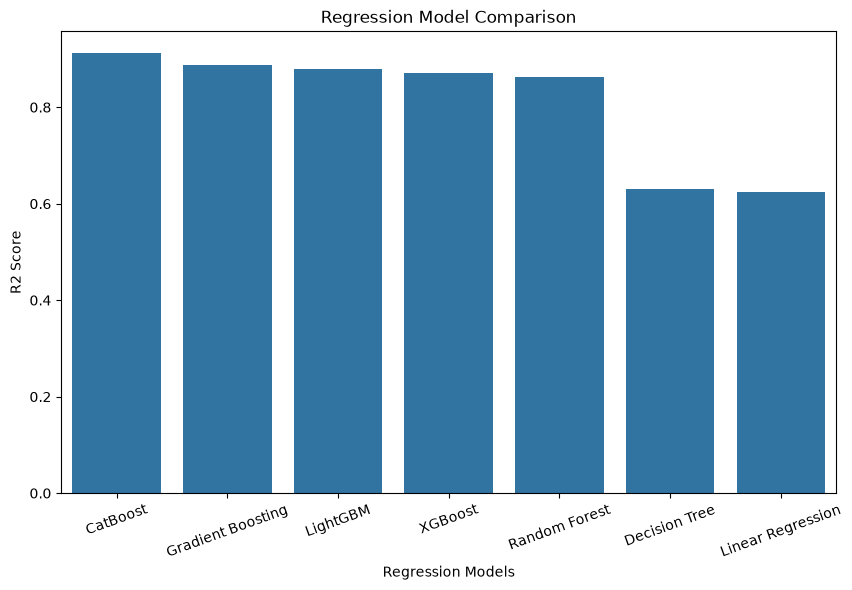

In [25]:
# Model Comparison Chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=20)

plt.title("Regression Model Comparison")

plt.xlabel("Regression Models")

plt.ylabel("R2 Score")

plt.show()

In [26]:
# Best Model

best = comparison.sort_values(
    by="R2 Score",
    ascending=False
).head(1)

best

,Model,MAE,MSE,RMSE,R2 Score
6,CatBoost,11480.855107,2.794843e+08,16717.78361,0.912134



### Conclusion

The model with the highest R² Score and lowest prediction error will be selected for optimization in the next phase.